In [2]:
import cv2
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

In [3]:
class HungrymanWorldEnvironment(gym.Env):
    """This class implements the Hungryman World environment."""

    def __init__(self, environment_type):
        """This method initializes the environment.

        :param str environment_type: - It can take two values: 1. 'deterministic' 2. 'stochastic'
                                       indicating the type of environment."""

        self.environment_type = environment_type

        self.environment_width = 5
        self.environment_height = 5

        self.observation_space = spaces.Discrete(self.environment_width * self.environment_height)
        self.action_space = spaces.Discrete(4)

        self.man_pos = np.asarray([0, 0])
        self.apple_pos = np.asarray([[1, 0], [3, 0], [2, 1], [4, 1], [1, 2], [3, 2], [0, 3]])
        self.cake_pos = np.asarray([4, 4])
        self.spider_pos = np.asarray([[2, 0], [3, 2], [2, 3], [4, 3]])
        self.dog_pos = np.asarray([[0, 2], [3, 3]])

        self.man_reward = 0
        self.apple_reward = 5
        self.cake_reward = 10
        self.spider_reward = -5
        self.dog_reward = -10

        reward_map = {(x, y): 0 for x in range(self.environment_width) for y in range(self.environment_height)}
        for pos in self.apple_pos:
            reward_map[tuple(pos)] += self.apple_reward
        for pos in self.spider_pos:
            reward_map[tuple(pos)] += self.spider_reward
        for pos in self.dog_pos:
            reward_map[tuple(pos)] += self.dog_reward
        reward_map[tuple(self.cake_pos)] += self.cake_reward
        self.reward_map = reward_map

    def reset(self):
        """This method resets the man position and returns the state as the observation.

        :returns int observation: -  Integer representing the grid block the man is in.
                 dict info: - A dictionary that can be used to provide additional implementation information."""
        self.man_pos = np.asarray([0, 0])
        self.man_reward = 0
        return self.man_pos

    def step(self, action):
        """This method implements what happens when the man takes a particular action. It changes the man's
        position (While not allowing it to go out of the environment space.), maps the environment co-ordinates to a
        state, defines the rewards for the various states, and determines when the episode ends.

        :param int action: - Integer in the range 0 to 3 inclusive representing the different actions the man can
        take.

        :returns arr observation: - Array representing the partial observation.
                 int reward: - Integer value that's used to measure the performance of the man.
                 bool terminated: - Boolean describing whether the episode has ended.
                 bool truncated: Boolean describing whether a truncation condition outside the scope of the MDP is
                                 satisfied.
                 dict info: - A dictionary that can be used to provide additional implementation information."""
        
        x, y = self.man_pos

        # Describing the outcomes of the various possible actions.
        if action == 0 and x < self.environment_width - 1:
            self.man_pos[0] += 1  # This action causes the man to go right.
        if action == 1 and x > 0:
            self.man_pos[0] -= 1  # This action causes the man to go left.
        if action == 2 and y < self.environment_height - 1:
            self.man_pos[1] += 1  # This action causes the man to go up.
        if action == 3 and y > 0:
            self.man_pos[1] -= 1  # This action causes the man to go down.

        reward = self.reward_map[self.man_pos[0], self.man_pos[1]]
        self.man_reward += reward

        # Print the current state, chosen action, and reward
        print(f"Current state: {x, y}, Action: {['right', 'left', 'up', 'down'][action]}, Reward: {reward}, Next state: {self.man_pos}")

        return

    def render(self, mode='human', plot=False):
        """This method renders the environment.

        :param str mode: 'human' renders to the current display or terminal and returns nothing.
        :param bool plot: Boolean indicating whether we show a plot or not. If False, the method returns a resized NumPy
                     array representation of the environment to be used as the state. If True it plots the environment.

        :returns arr preprocessed_image: Grayscale NumPy array representation of the environment."""

        fig, ax = plt.subplots(figsize=(15, 15))
        ax.set_xlim(0, 5)
        ax.set_ylim(0, 5)

        def plot_image(plot_pos):
            """This is a helper function to render the environment. It checks which objects are in a particular
            position on the grid and renders the appropriate image.

            :param arr plot_pos: Co-ordinates of the grid position which needs to be rendered."""

            # Initially setting every object to not be plotted.
            plot_man, plot_apple, plot_cake, plot_spider, plot_dog = \
                False, False, False, False, False

            # Checking which objects need to be plotted by comparing their positions.
            if np.array_equal(self.man_pos, plot_pos):
                plot_man = True
            if any(np.array_equal(self.apple_pos[i], plot_pos) for i in range(len(self.apple_pos))):
                plot_apple = True
            if np.array_equal(plot_pos, self.cake_pos):
                plot_cake = True
            if any(np.array_equal(self.spider_pos[i], plot_pos) for i in range(len(self.spider_pos))):
                plot_spider = True
            if any(np.array_equal(self.dog_pos[i], plot_pos) for i in range(len(self.dog_pos))):
                plot_dog = True

            # Plot for Man.
            if plot_man and \
                    all(not item for item in
                        [plot_apple, plot_cake, plot_spider, plot_dog]):
                man = AnnotationBbox(OffsetImage(plt.imread('./images/man.png'), zoom=0.20),
                                       np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(man)

            # Plot for Apple.
            elif plot_apple and \
                    all(not item for item in
                        [plot_man, plot_cake, plot_spider, plot_dog]):
                apple = AnnotationBbox(OffsetImage(plt.imread('./images/apple.png'), zoom=0.20),
                                        np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(apple)

            # Plot for Cake.
            elif plot_cake and \
                    all(not item for item in
                        [plot_man, plot_apple, plot_spider, plot_dog]):
                cake = AnnotationBbox(OffsetImage(plt.imread('./images/cake.png'), zoom=0.20),
                                      np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(cake)
                
            # Plot for Spider.
            elif plot_spider and \
                    all(not item for item in
                        [plot_man, plot_apple, plot_cake, plot_dog]):
                spider = AnnotationBbox(OffsetImage(plt.imread('./images/spider.png'), zoom=0.20),
                                        np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(spider)

            # Plot for Dog.
            elif plot_dog and \
                    all(not item for item in
                        [plot_man, plot_apple, plot_cake, plot_spider]):
                dog = AnnotationBbox(OffsetImage(plt.imread('./images/dog.png'), zoom=0.20),
                                        np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(dog)

            # Plot for Man and Apple.
            elif all(item for item in [plot_man, plot_apple]) and \
                    all(not item for item in
                        [plot_cake, plot_spider, plot_dog]):
                man_apple = AnnotationBbox(OffsetImage(plt.imread('./images/man_apple.png'), zoom=0.20),
                                              np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(man_apple)

            # Plot for Man and Spider.
            elif all(item for item in [plot_man, plot_spider]) and \
                    all(not item for item in
                        [plot_apple, plot_cake, plot_dog]):
                man_spider = AnnotationBbox(OffsetImage(plt.imread('./images/man_spider.png'), zoom=0.20),
                                              np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(man_spider)

            # Plot for Man, Apple and Spider.
            elif all(item for item in [plot_man, plot_apple, plot_spider]) and \
                    all(not item for item in
                        [plot_cake, plot_dog]):
                man_apple_spider = AnnotationBbox(OffsetImage(plt.imread('./images/man_apple_spider.png'),
                                                                 zoom=0.20), np.add(plot_pos, [0.5, 0.5]),
                                                     frameon=False)
                ax.add_artist(man_apple_spider)

            # Plot for Man and Dog.
            elif all(item for item in [plot_man, plot_dog]) and \
                    all(not item for item in
                        [plot_cake, plot_spider, plot_apple]):
                man_dog = AnnotationBbox(OffsetImage(plt.imread('./images/man_dog.png'),
                                                          zoom=0.28), np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(man_dog)

            # Plot for Apple and Spider.
            elif all(item for item in [plot_apple, plot_spider]) and \
                    all(not item for item in
                        [plot_man, plot_cake, plot_dog]):
                apple_spider = AnnotationBbox(OffsetImage(plt.imread('./images/apple_spider.png'), zoom=0.20),
                                               np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(apple_spider)

            # Plot for Man and Cake.
            elif all(item for item in [plot_man, plot_cake]) and \
                    all(not item for item in
                        [plot_apple, plot_spider, plot_dog]):
                man_cake = AnnotationBbox(OffsetImage(plt.imread('./images/man_cake.png'), zoom=0.20),
                                              np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(man_cake)

        coordinates_state_mapping_2 = {}
        for j in range(self.environment_height * self.environment_width):
            coordinates_state_mapping_2[j] = np.asarray(
                [j % self.environment_width, int(np.floor(j / self.environment_width))])

        # Rendering the images for all states.
        for position in coordinates_state_mapping_2:
            plot_image(coordinates_state_mapping_2[position])

        plt.xticks([0, 1, 2, 3, 4])
        plt.yticks([0, 1, 2, 3, 4])
        plt.grid()

        if plot:  # Displaying the plot.
            plt.show()
        else:  # Returning the preprocessed image representation of the environment.
            fig.canvas.draw()
            img = np.array(fig.canvas.renderer.buffer_rgba())[:, :, :3]
            width = 70
            height = 70
            dim = (width, height)
            # noinspection PyUnresolvedReferences
            preprocessed_image = cv2.resize(img, dim, interpolation=cv2.INTER_AREA)
            plt.show()
            return preprocessed_image

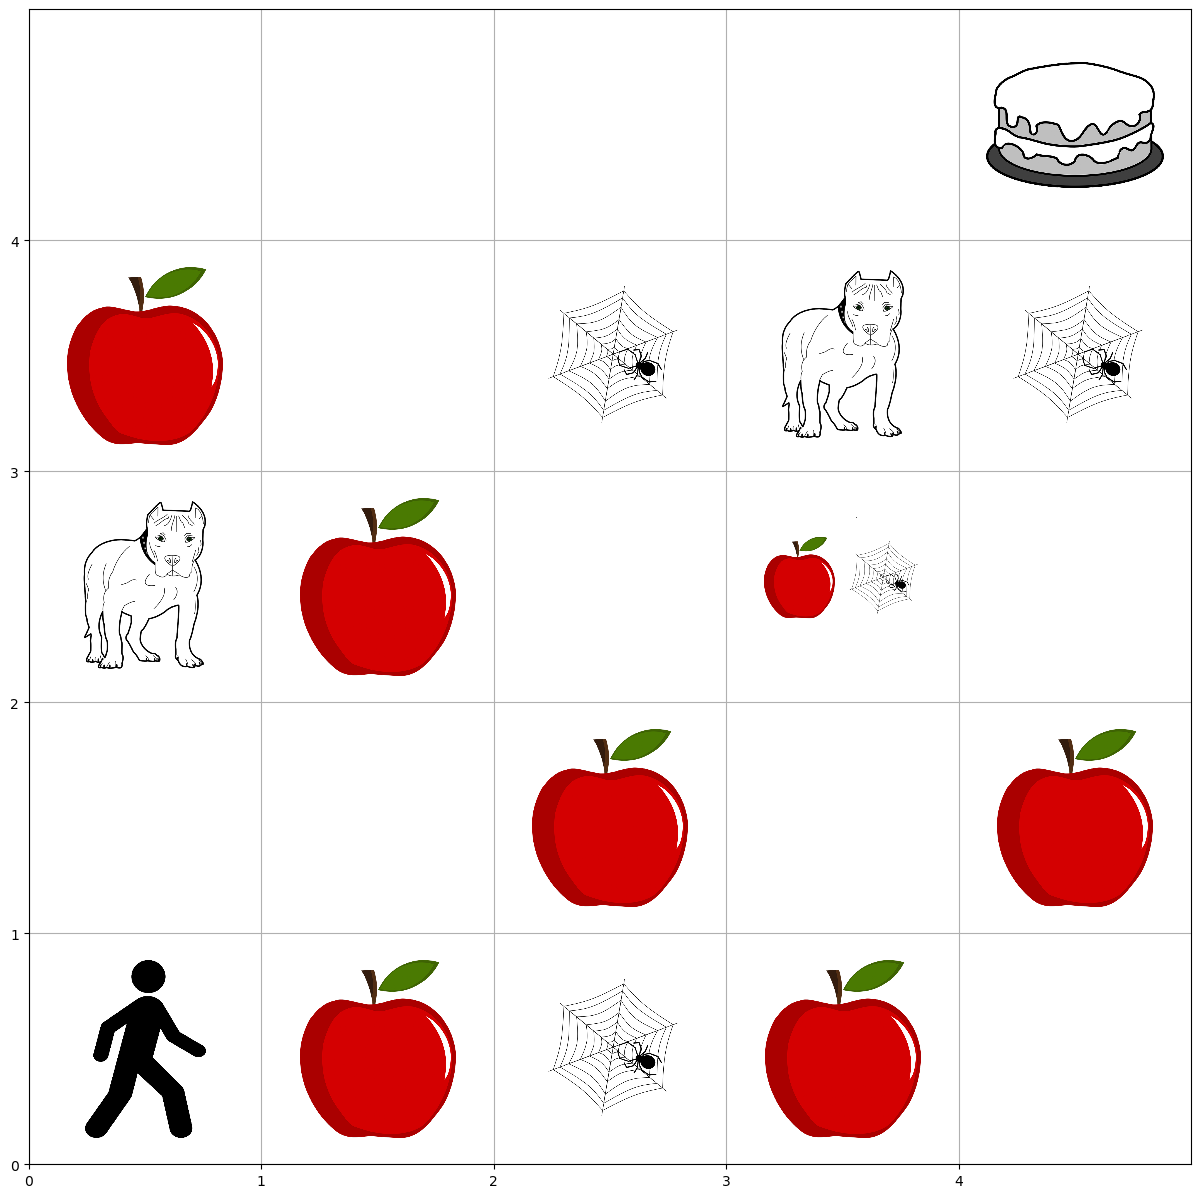

Current state: (0, 0), Action: up, Reward: 0, Next state: [0 1]


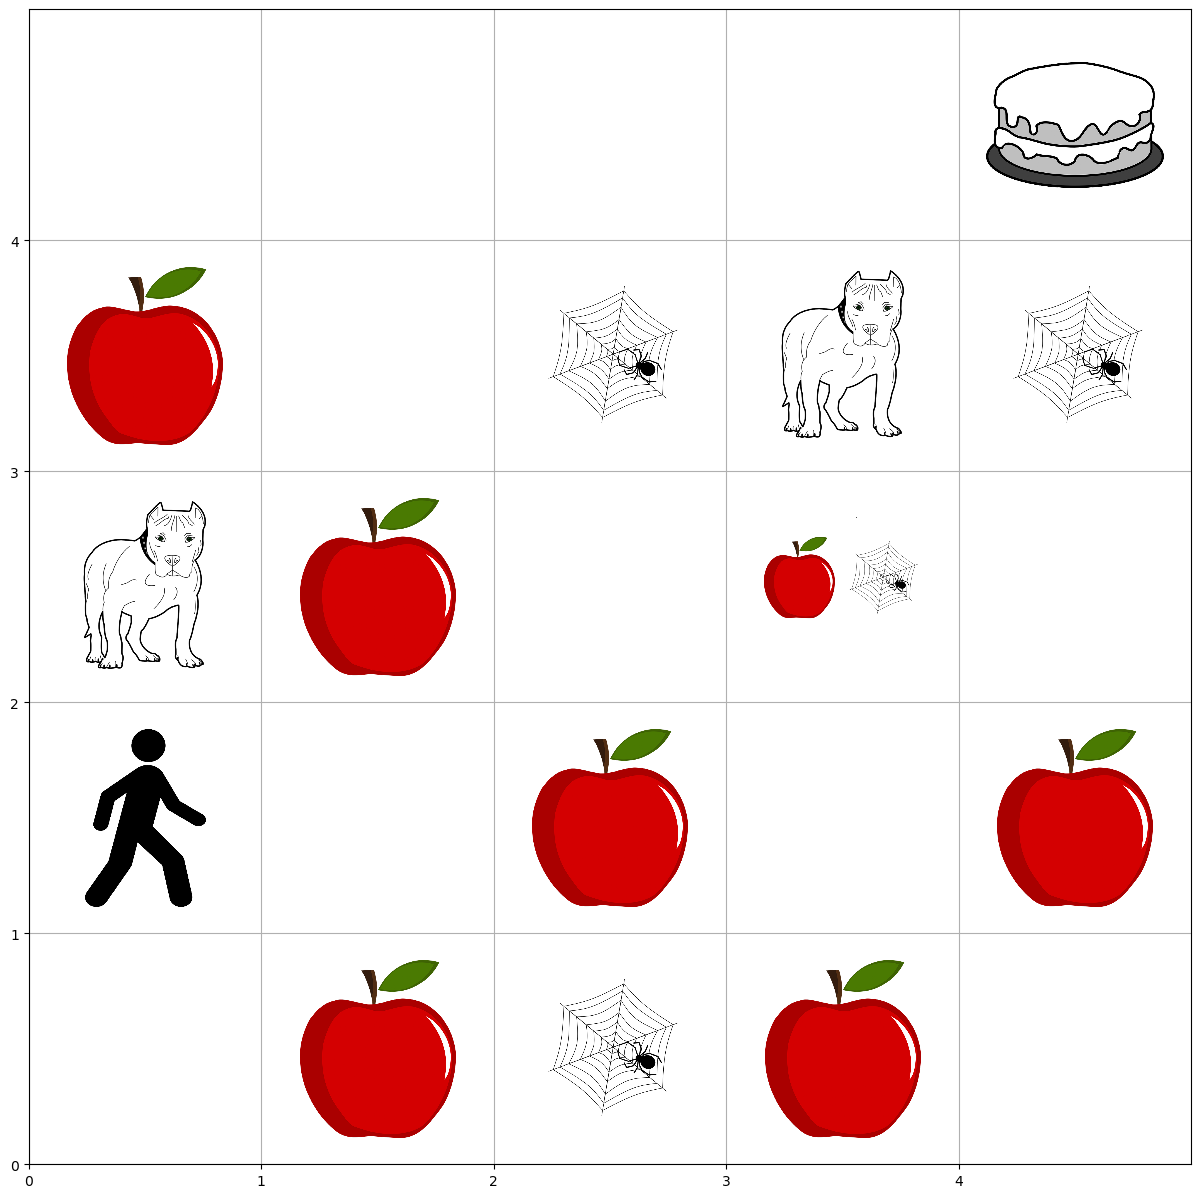

Current state: (0, 1), Action: left, Reward: 0, Next state: [0 1]


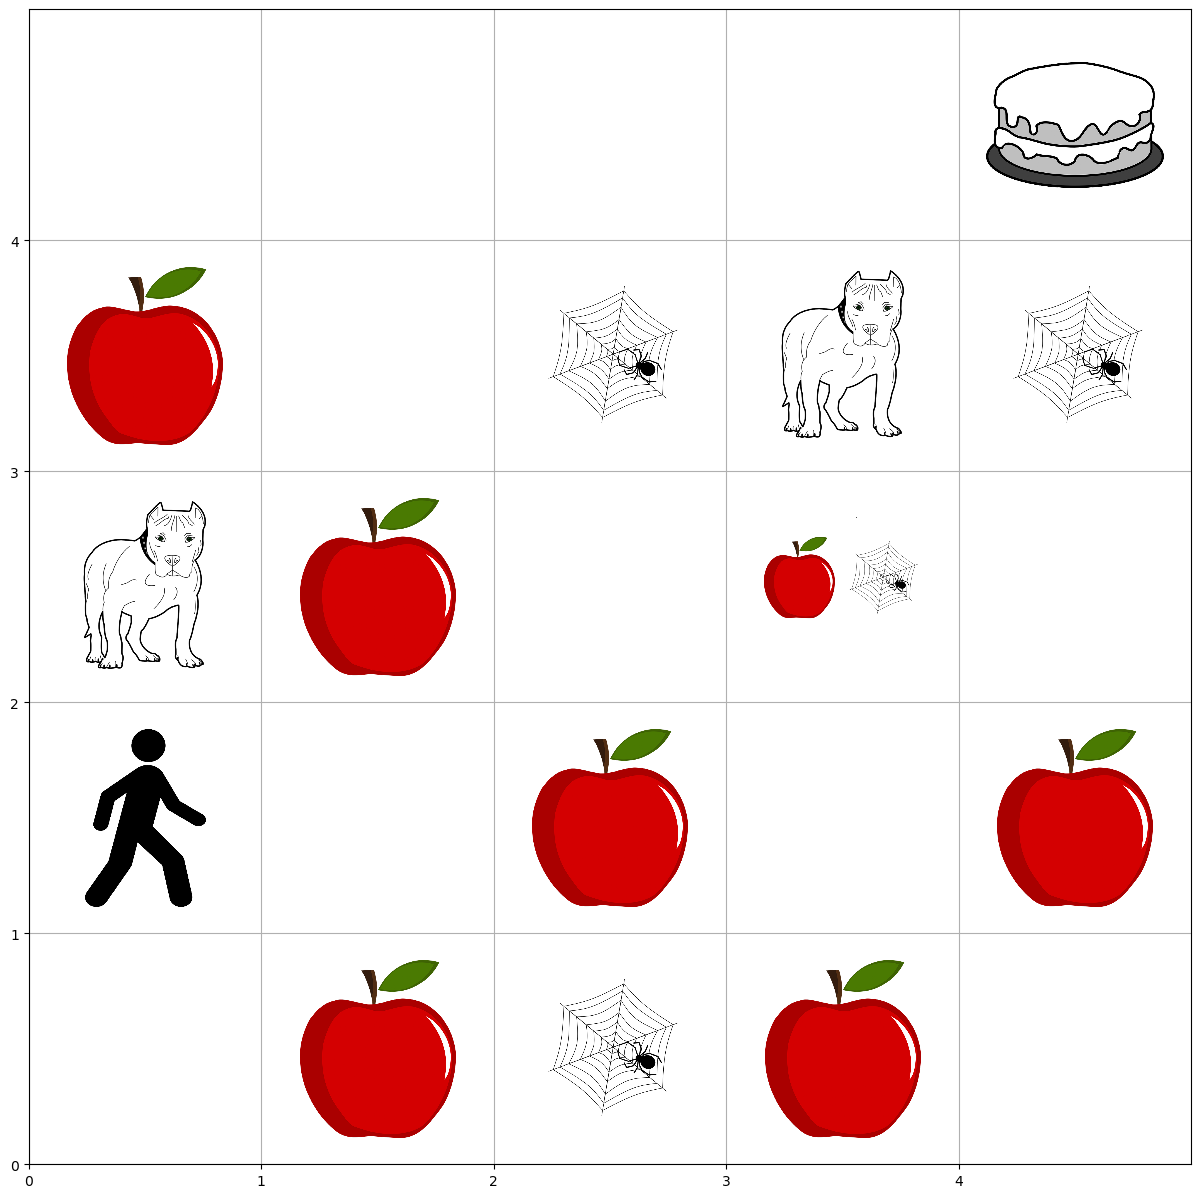

Current state: (0, 1), Action: up, Reward: -10, Next state: [0 2]


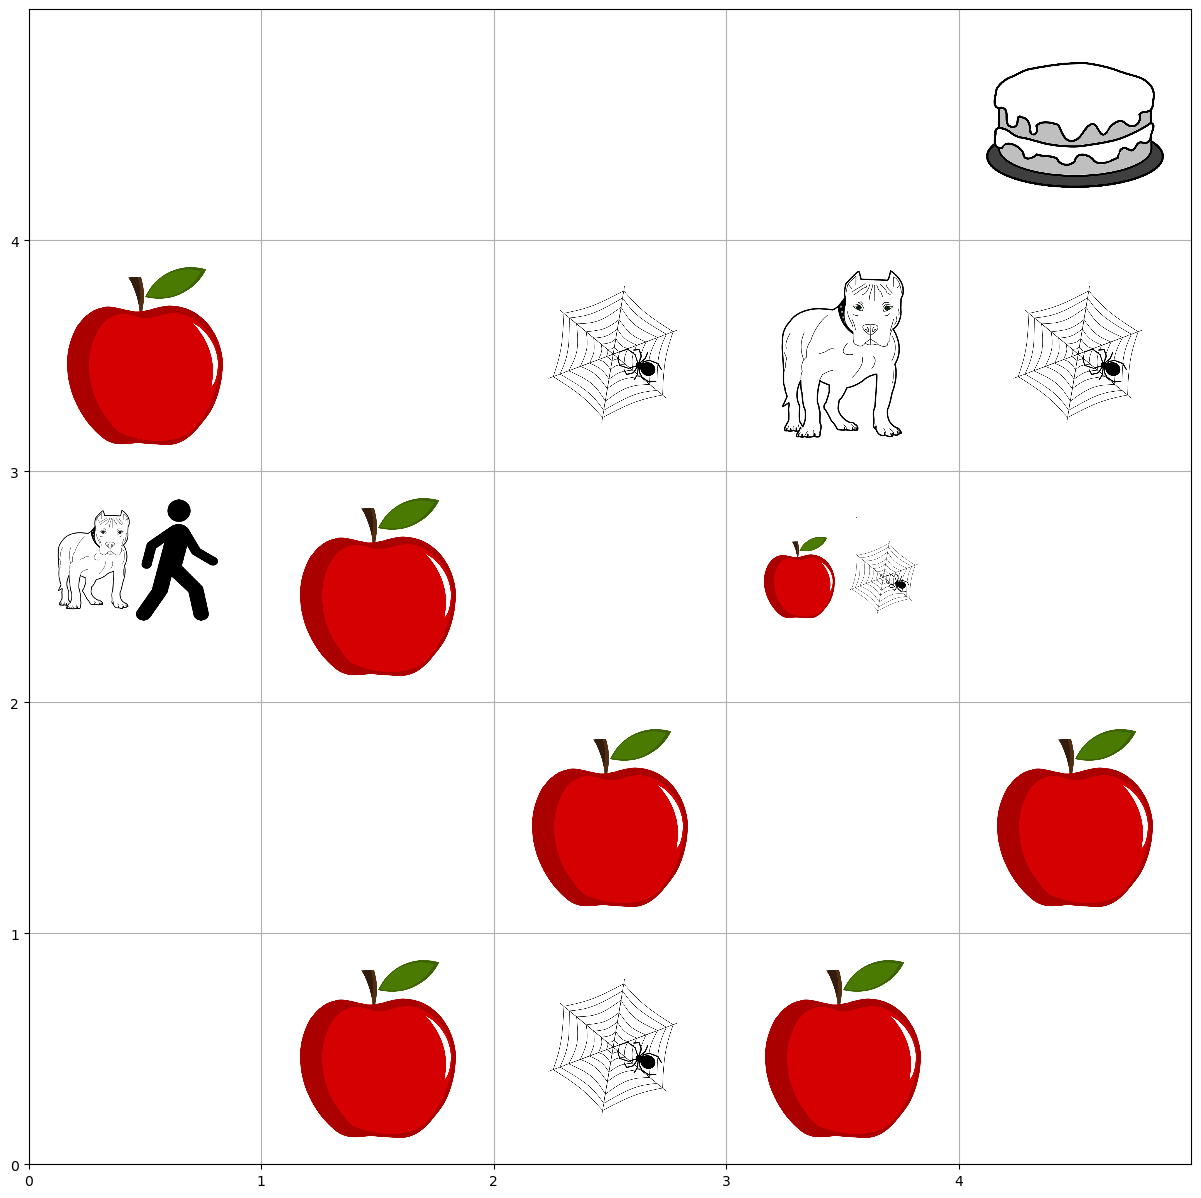

Current state: (0, 2), Action: right, Reward: 5, Next state: [1 2]


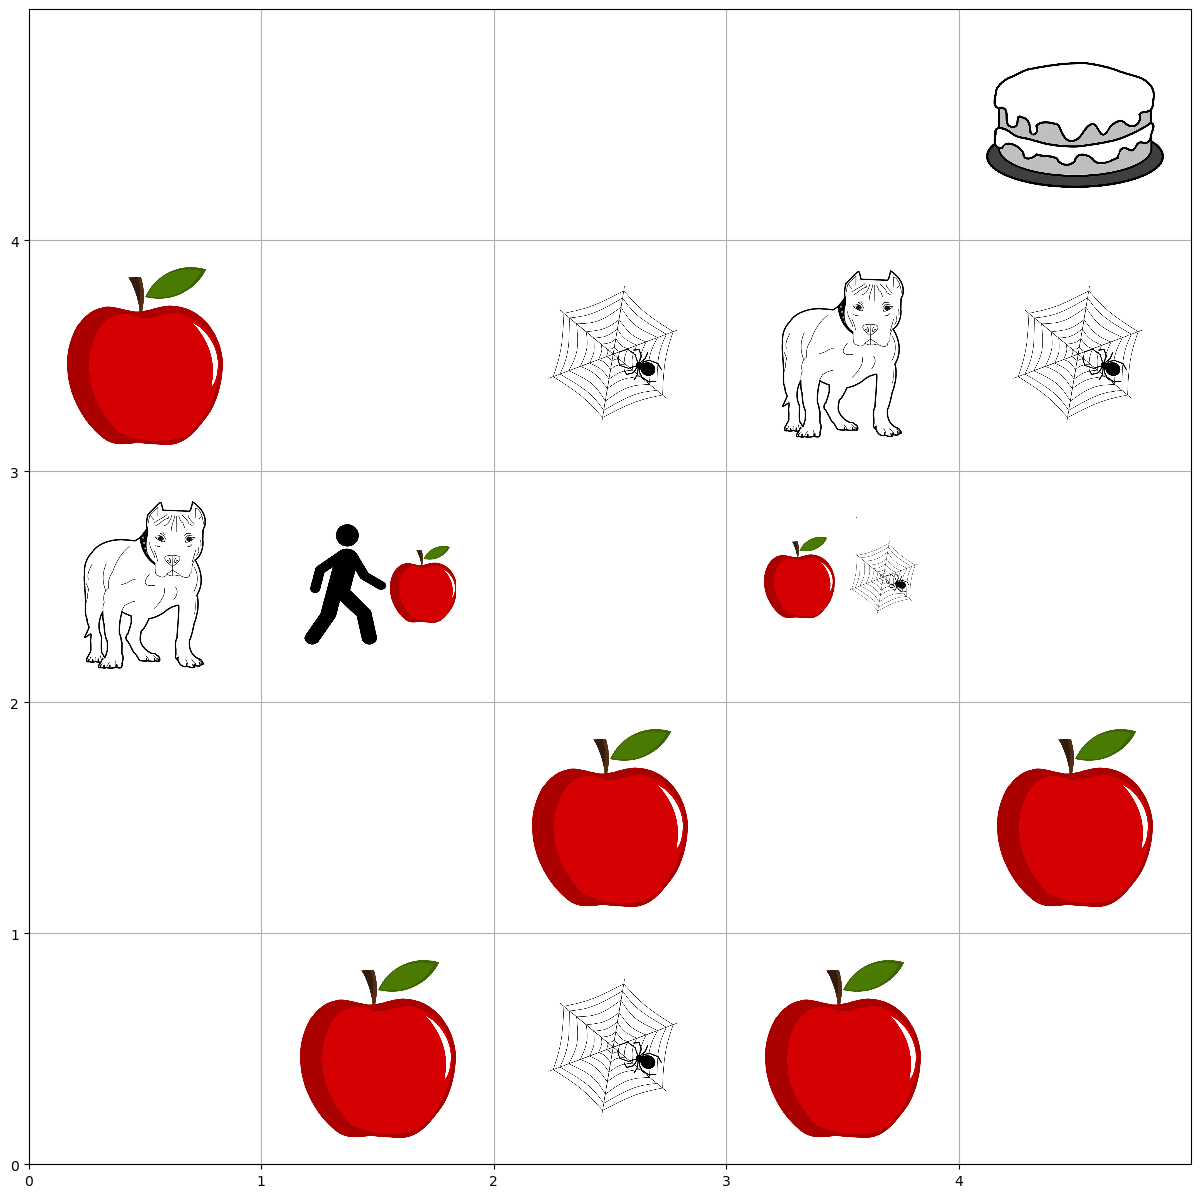

Current state: (1, 2), Action: up, Reward: 0, Next state: [1 3]


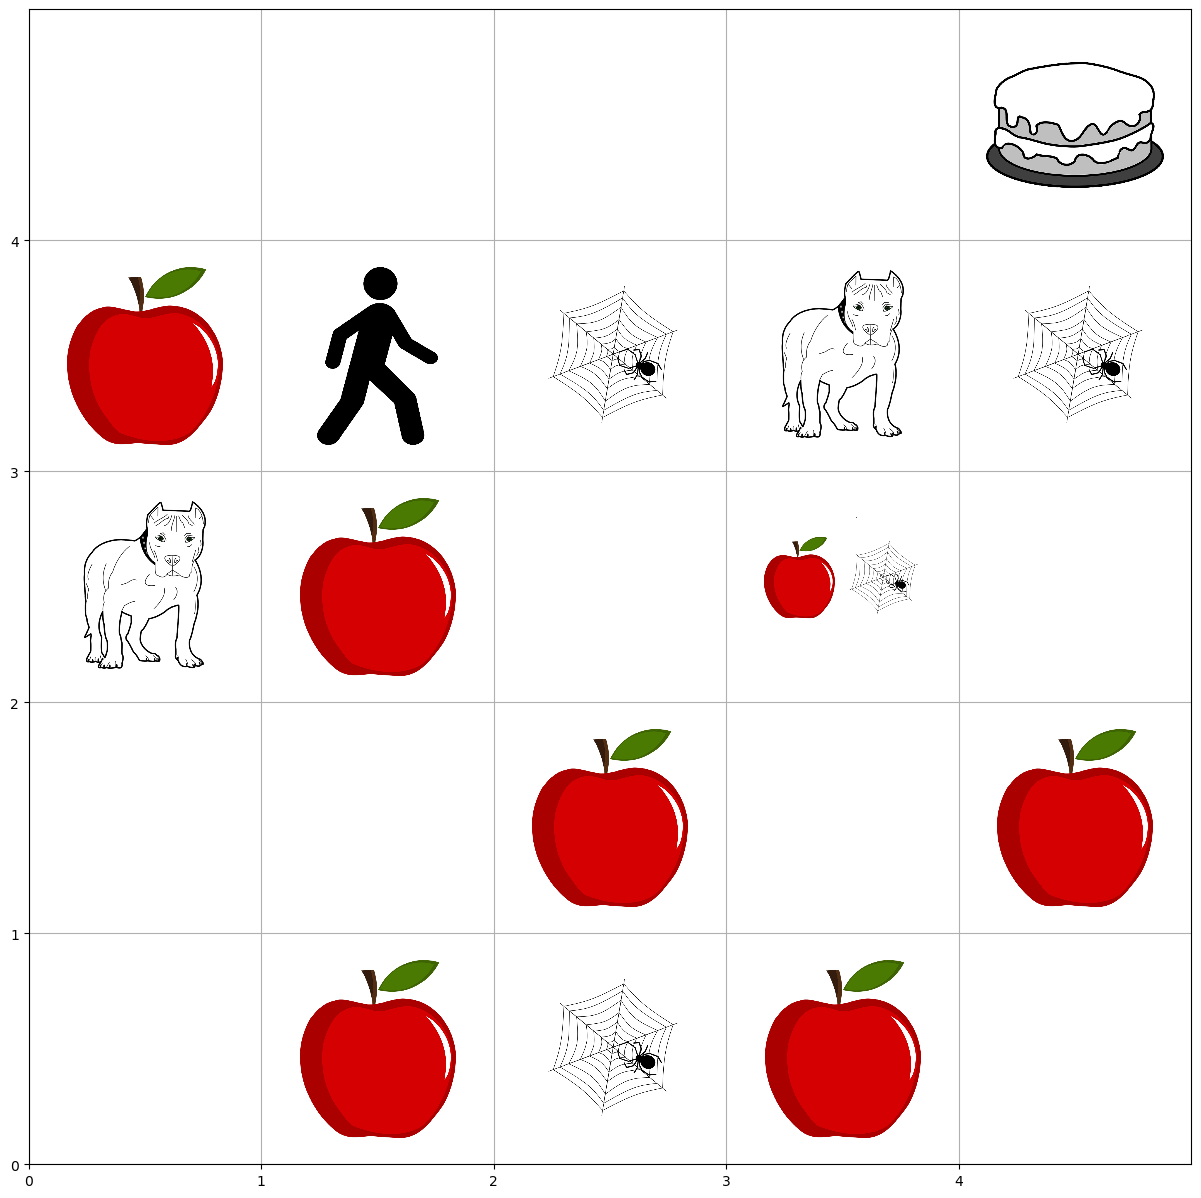

Current state: (1, 3), Action: right, Reward: -5, Next state: [2 3]


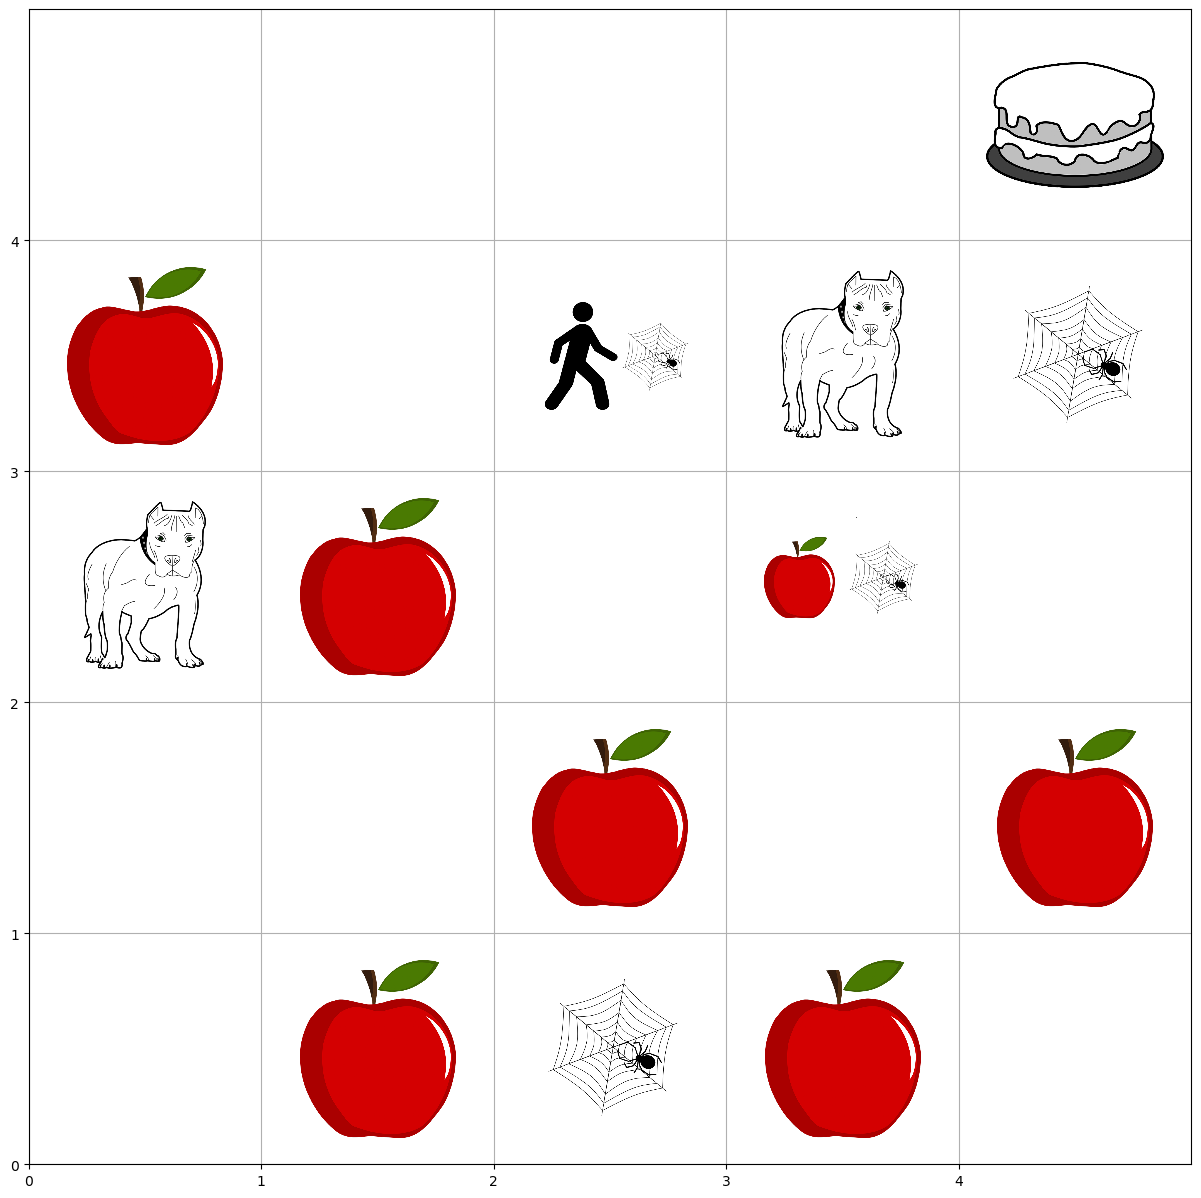

Current state: (2, 3), Action: up, Reward: 0, Next state: [2 4]


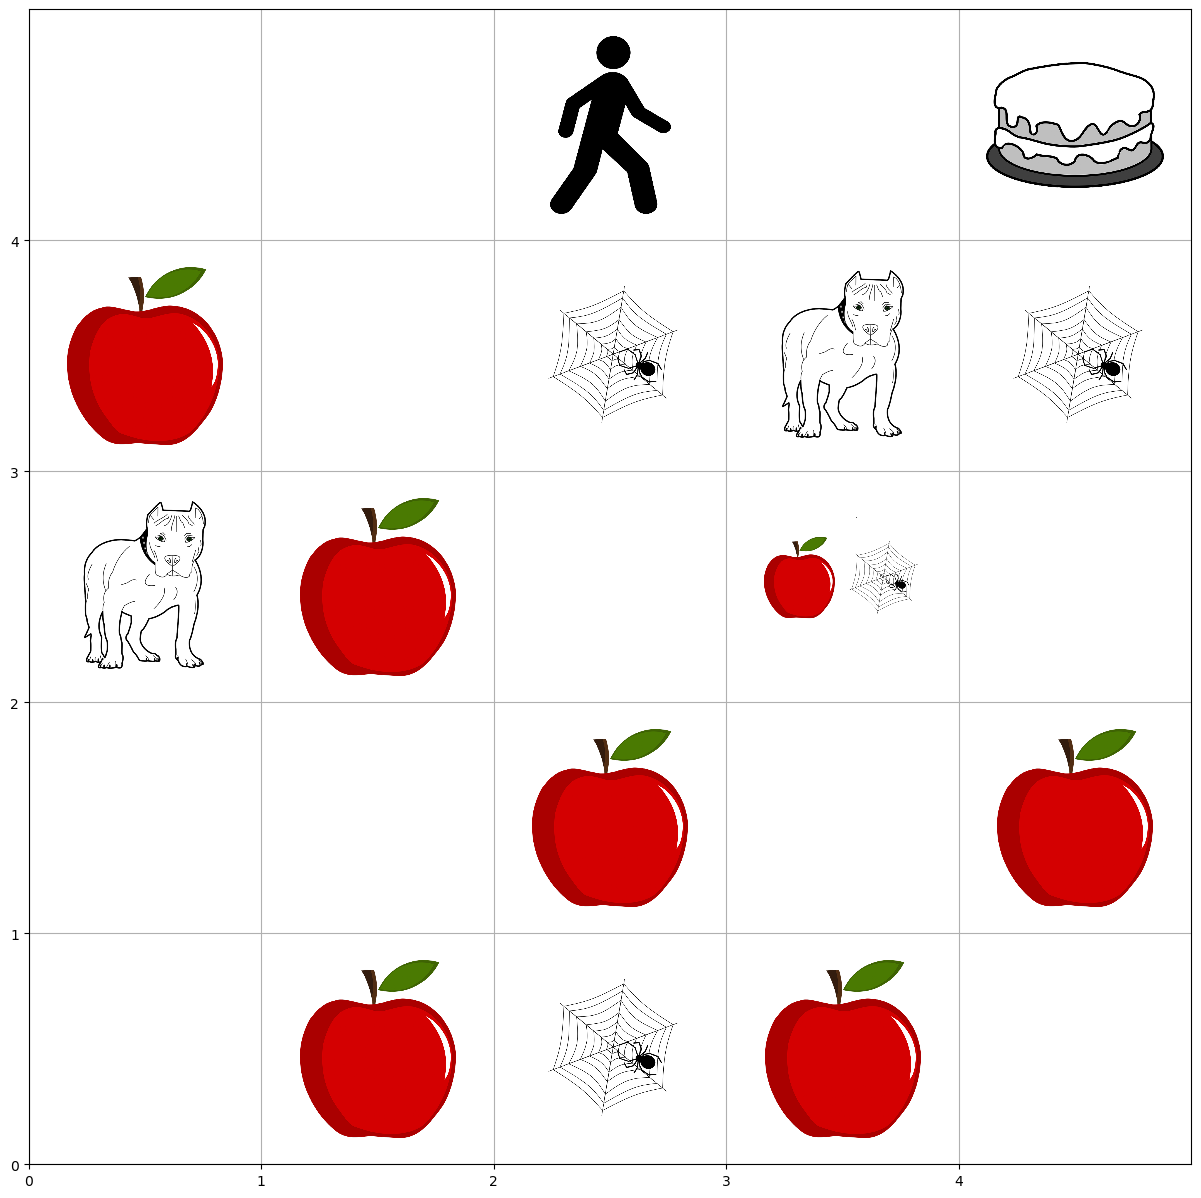

Current state: (2, 4), Action: up, Reward: 0, Next state: [2 4]


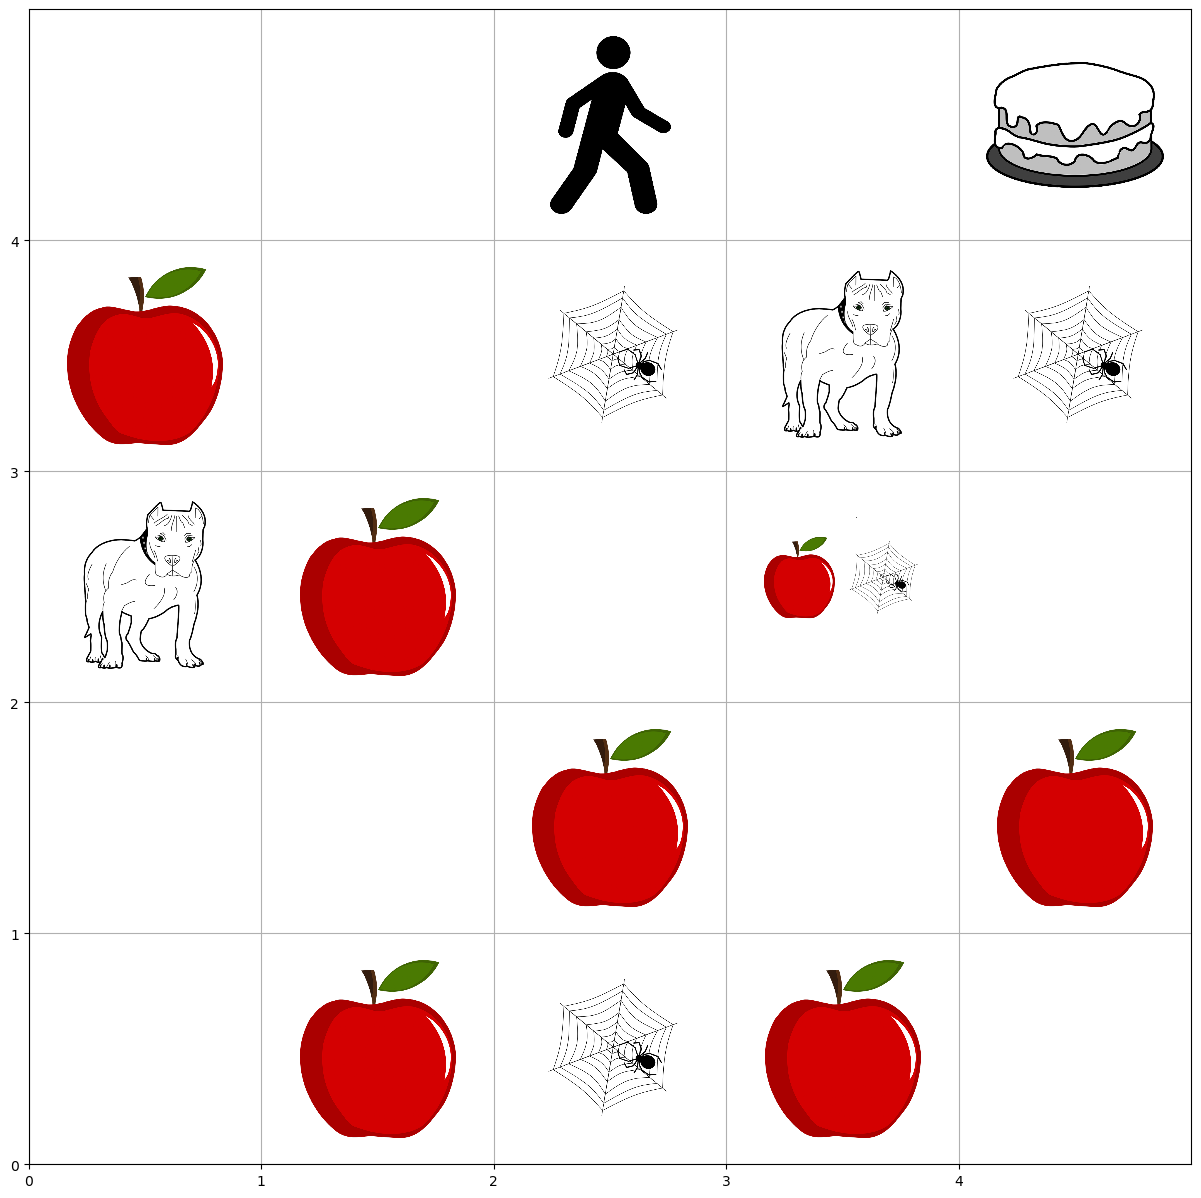

Current state: (2, 4), Action: right, Reward: 0, Next state: [3 4]


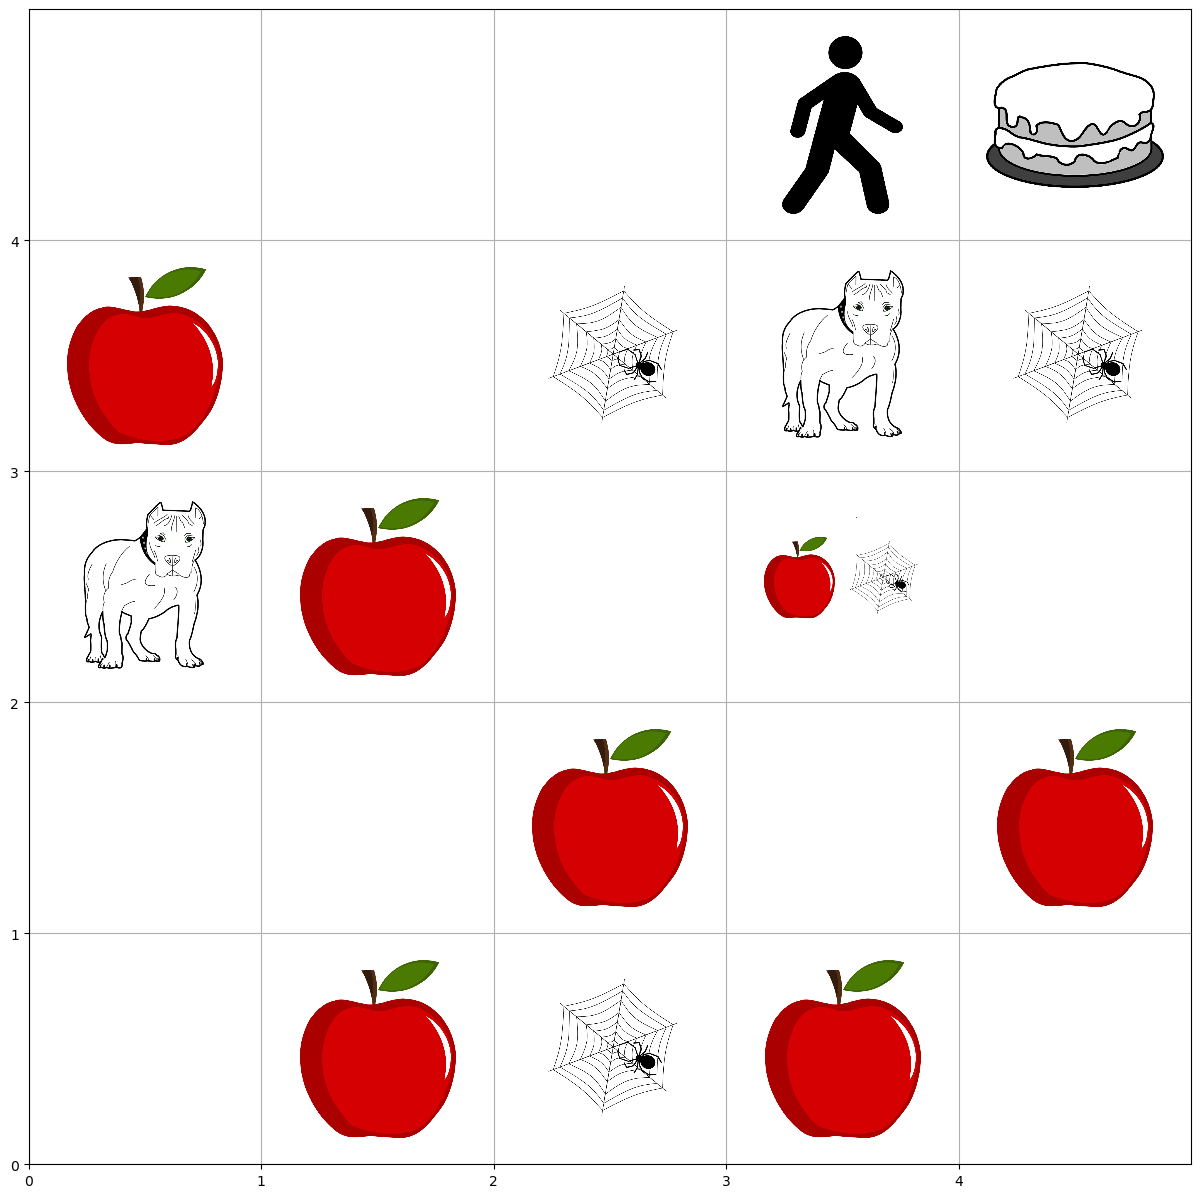

Current state: (3, 4), Action: up, Reward: 0, Next state: [3 4]


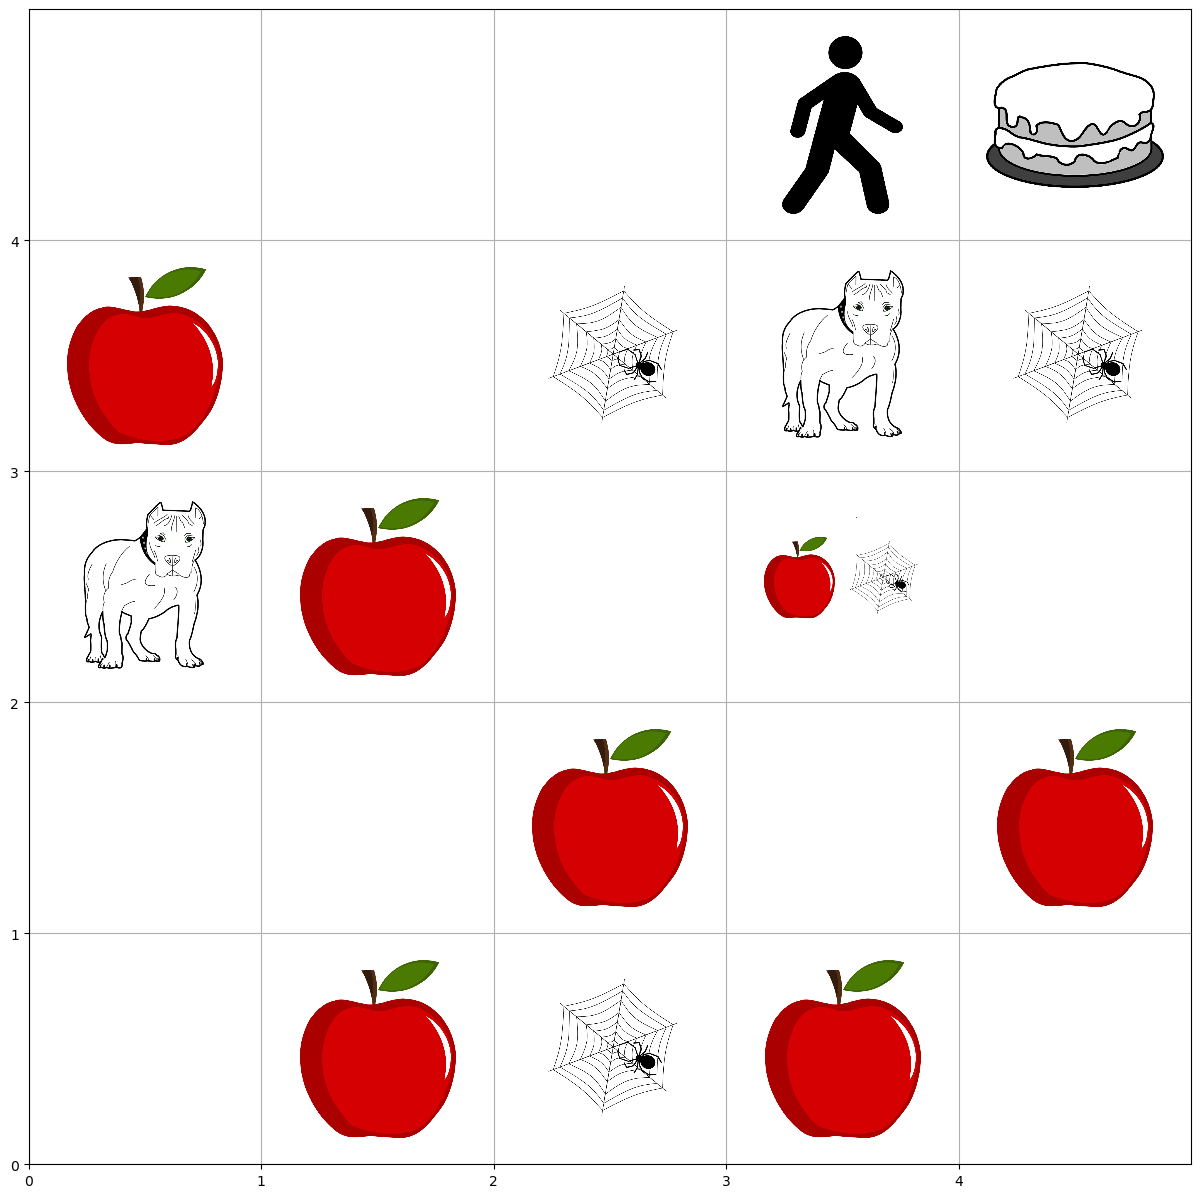

In [ ]:
hungryman_world = HungrymanWorldEnvironment(environment_type='deterministic')
hungryman_world.reset()
hungryman_world.render(plot=True)
for i in range(10):
    action = hungryman_world.action_space.sample()
    hungryman_world.step(action)
    hungryman_world.render(plot=True)

### References
- hungryman_world.py from 'visualizing_rl_environments_and_representing_the_results (2)'
- images: 'stick-man-walking-hiking', 'dog-animal-pet-canine-bull-pit', 'apple-fruit-red-healthy-diet', 'spider-spiderweb', 'cake-birthday-sugar-icing-party' Pixabay
- https://gymnasium.farama.org/api/spaces/